# Network Anomaly Detection — ML (Major Project Notebook)

This notebook is an advanced ML anomaly detection workflow for network traffic using **NSL-KDD**.

## Scope
1. Real benchmark dataset ingestion
2. Deep EDA and class-wise traffic pattern analysis
3. Robust preprocessing for mixed features
4. Unsupervised anomaly model training on normal traffic only
5. Multi-model evaluation dashboard (Isolation Forest, LOF, One-Class SVM)
6. ROC/PR curves, confusion matrices, threshold-quality analysis
7. Attack-type-wise recall diagnostics
8. Artifact export and reusable inference utility

In [1]:
import json
import warnings
from pathlib import Path
from urllib.request import urlretrieve

import joblib
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from scipy.stats import ks_2samp
from sklearn.preprocessing import OrdinalEncoder, StandardScaler
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.svm import OneClassSVM
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import (
    classification_report, accuracy_score, confusion_matrix,
    precision_recall_fscore_support, roc_auc_score, average_precision_score,
    roc_curve, precision_recall_curve, f1_score
)

SEED = 42
np.random.seed(SEED)
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')

ROOT = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd().resolve()
DATA_DIR = ROOT / 'data'
ARTIFACT_DIR = ROOT / 'checkpoints' / 'ml_models_major'
PLOT_DIR = ROOT / 'extra' / 'notebook_plots'
DATA_DIR.mkdir(parents=True, exist_ok=True)
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)
PLOT_DIR.mkdir(parents=True, exist_ok=True)

print('Root:', ROOT)
print('Data dir:', DATA_DIR)
print('Artifacts dir:', ARTIFACT_DIR)

Root: C:\Users\shain\Downloads\Network-Anomaly-Detection
Data dir: C:\Users\shain\Downloads\Network-Anomaly-Detection\data
Artifacts dir: C:\Users\shain\Downloads\Network-Anomaly-Detection\checkpoints\ml_models_major


In [2]:
# NSL-KDD mirrors
urls = {
    'train': 'https://raw.githubusercontent.com/defcom17/NSL_KDD/master/KDDTrain%2B.txt',
    'test': 'https://raw.githubusercontent.com/defcom17/NSL_KDD/master/KDDTest%2B.txt'
}

train_path = DATA_DIR / 'KDDTrain+.txt'
test_path = DATA_DIR / 'KDDTest+.txt'

if not train_path.exists():
    urlretrieve(urls['train'], train_path.as_posix())
if not test_path.exists():
    urlretrieve(urls['test'], test_path.as_posix())

print('Dataset ready:', train_path.exists(), test_path.exists())
print('Train:', train_path)
print('Test :', test_path)

Dataset ready: True True
Train: C:\Users\shain\Downloads\Network-Anomaly-Detection\data\KDDTrain+.txt
Test : C:\Users\shain\Downloads\Network-Anomaly-Detection\data\KDDTest+.txt


In [3]:
NSL_KDD_COLUMNS = [
    'duration','protocol_type','service','flag','src_bytes','dst_bytes','land','wrong_fragment',
    'urgent','hot','num_failed_logins','logged_in','num_compromised','root_shell','su_attempted',
    'num_root','num_file_creations','num_shells','num_access_files','num_outbound_cmds',
    'is_host_login','is_guest_login','count','srv_count','serror_rate','srv_serror_rate',
    'rerror_rate','srv_rerror_rate','same_srv_rate','diff_srv_rate','srv_diff_host_rate',
    'dst_host_count','dst_host_srv_count','dst_host_same_srv_rate','dst_host_diff_srv_rate',
    'dst_host_same_src_port_rate','dst_host_srv_diff_host_rate','dst_host_serror_rate',
    'dst_host_srv_serror_rate','dst_host_rerror_rate','dst_host_srv_rerror_rate','label','difficulty'
    ]

train_df = pd.read_csv(train_path, names=NSL_KDD_COLUMNS)
test_df = pd.read_csv(test_path, names=NSL_KDD_COLUMNS)

print('Train shape:', train_df.shape)
print('Test shape :', test_df.shape)
print('Missing values train/test:', train_df.isna().sum().sum(), test_df.isna().sum().sum())
display(train_df.head(3))

Train shape: (125973, 43)
Test shape : (22544, 43)
Missing values train/test: 0 0


,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,label,difficulty
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,0.17,0.03,0.17,0.0,0.0,0.0,0.05,0.0,normal,20
1,0,udp,other,SF,146,0,0,0,0,0,...,0.00,0.60,0.88,0.0,0.0,0.0,0.00,0.0,normal,15
2,0,tcp,private,S0,0,0,0,0,0,0,...,0.10,0.05,0.00,0.0,1.0,1.0,0.00,0.0,neptune,19


Binary class distribution (train):


,ratio
label,
0,0.534583
1,0.465417


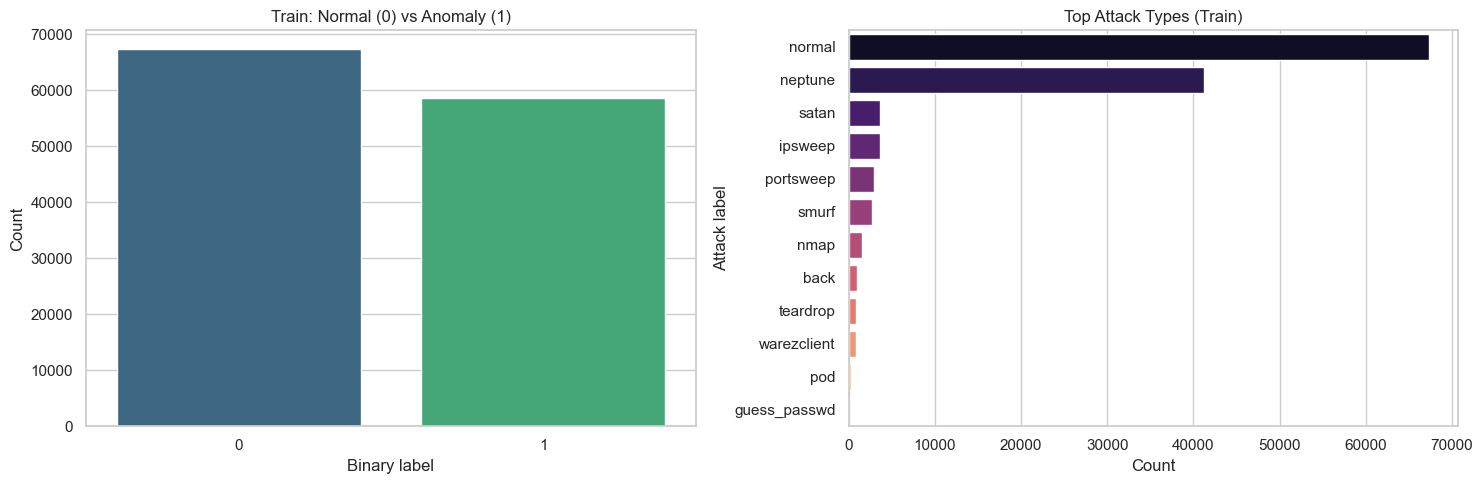

,count,mean,std,min,25%,50%,75%,max
duration,125973.0,287.144650,2.604515e+03,0.0,0.0,0.0,0.0,4.290800e+04
src_bytes,125973.0,45566.743000,5.870331e+06,0.0,0.0,44.0,276.0,1.379964e+09
dst_bytes,125973.0,19779.114421,4.021269e+06,0.0,0.0,0.0,516.0,1.309937e+09
land,125973.0,0.000198,1.408607e-02,0.0,0.0,0.0,0.0,1.000000e+00
wrong_fragment,125973.0,0.022687,2.535300e-01,0.0,0.0,0.0,0.0,3.000000e+00
urgent,125973.0,0.000111,1.436603e-02,0.0,0.0,0.0,0.0,3.000000e+00
hot,125973.0,0.204409,2.149968e+00,0.0,0.0,0.0,0.0,7.700000e+01
num_failed_logins,125973.0,0.001222,4.523914e-02,0.0,0.0,0.0,0.0,5.000000e+00
logged_in,125973.0,0.395736,4.890101e-01,0.0,0.0,0.0,1.0,1.000000e+00
num_compromised,125973.0,0.279250,2.394204e+01,0.0,0.0,0.0,0.0,7.479000e+03


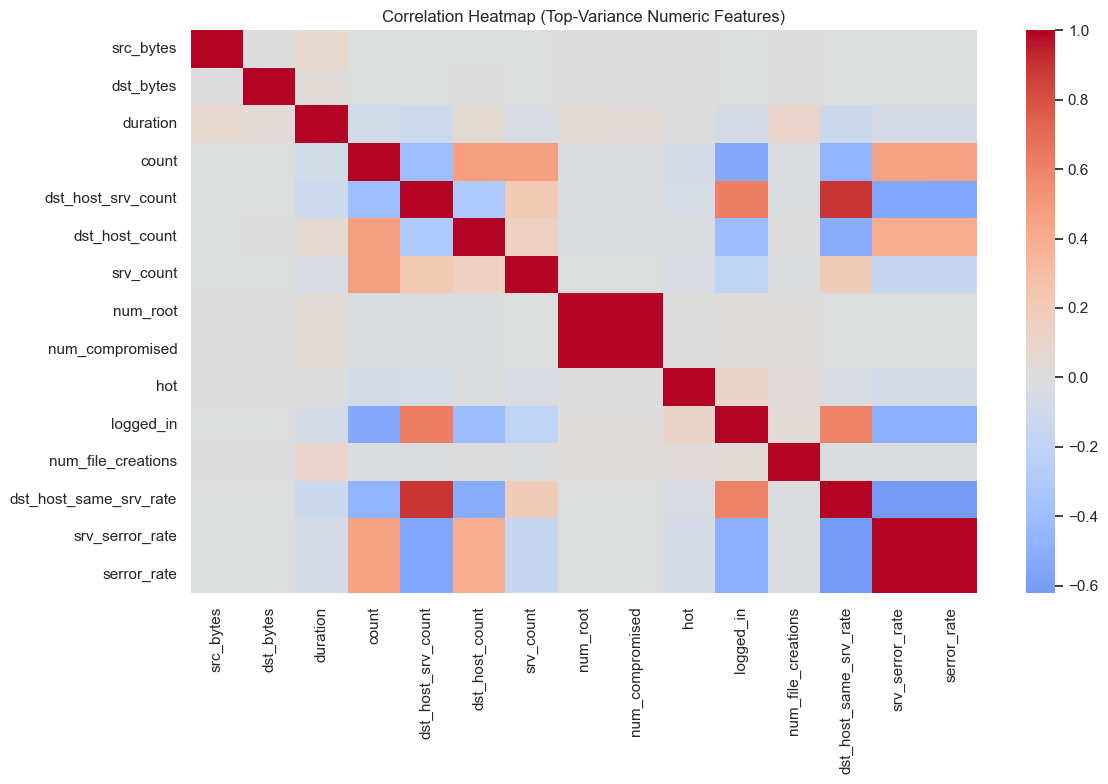

In [4]:
# ---------- Deep EDA ----------
train_attack_series = train_df['label'].astype(str)
train_binary = (train_attack_series != 'normal').astype(int)

print('Binary class distribution (train):')
display(train_binary.value_counts(normalize=True).rename('ratio').to_frame())

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.countplot(x=train_binary, ax=axes[0], palette='viridis')
axes[0].set_title('Train: Normal (0) vs Anomaly (1)')
axes[0].set_xlabel('Binary label')
axes[0].set_ylabel('Count')

attack_order = train_attack_series.value_counts().head(12).index
sns.countplot(y=train_attack_series, order=attack_order, ax=axes[1], palette='magma')
axes[1].set_title('Top Attack Types (Train)')
axes[1].set_xlabel('Count')
axes[1].set_ylabel('Attack label')
plt.tight_layout()
plt.show()

num_cols_eda = [c for c in train_df.select_dtypes(include=[np.number]).columns if c != 'difficulty']
display(train_df[num_cols_eda].describe().T.head(12))

var_rank = train_df[num_cols_eda].var().sort_values(ascending=False).head(15).index.tolist()
corr = train_df[var_rank].corr()
plt.figure(figsize=(12, 8))
sns.heatmap(corr, cmap='coolwarm', center=0)
plt.title('Correlation Heatmap (Top-Variance Numeric Features)')
plt.tight_layout()
plt.show()

## Advanced EDA Diagnostics

This section adds class-conditional categorical distributions, KS-based feature ranking, and dimensionality-reduction views for separability insights.

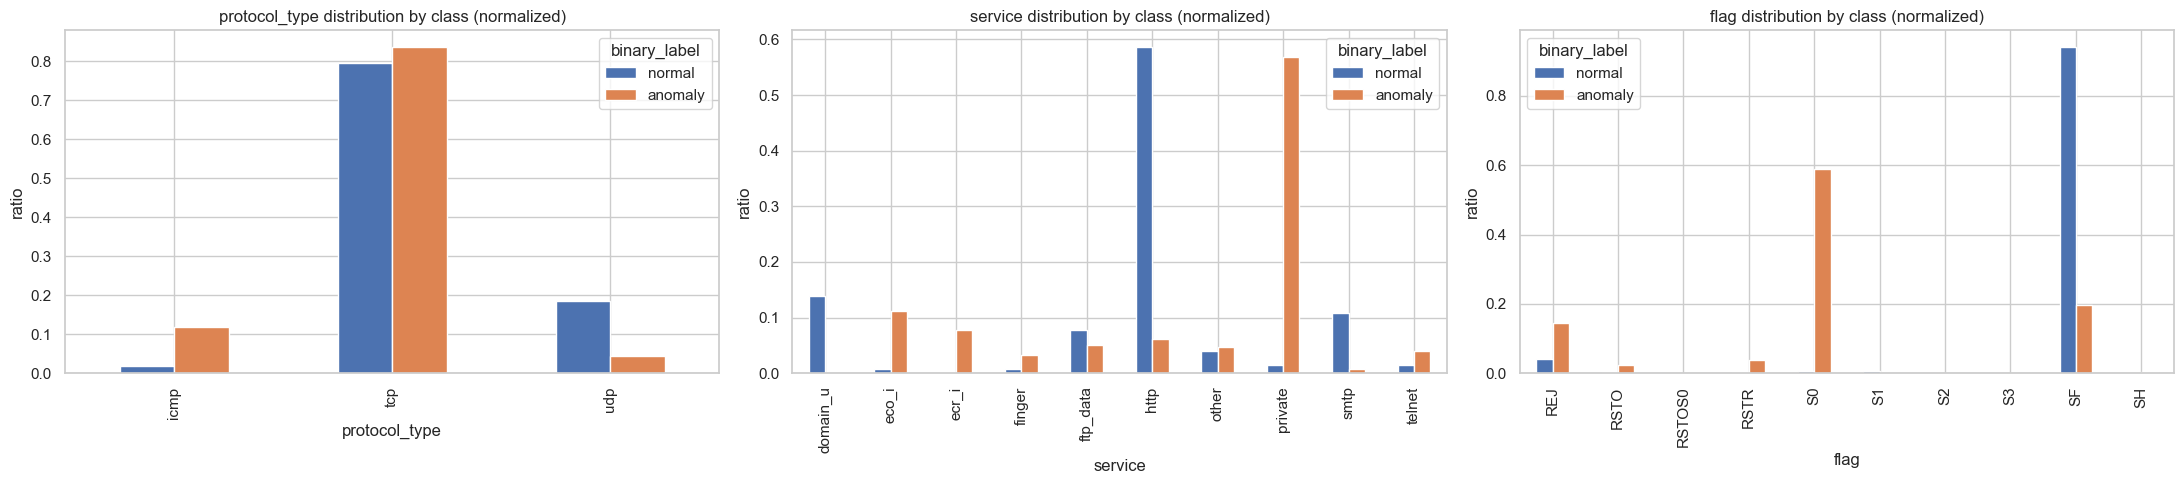

,feature,ks_stat,p_value
1,src_bytes,0.843140,0.0
2,dst_bytes,0.809802,0.0
25,same_srv_rate,0.721889,0.0
26,diff_srv_rate,0.720754,0.0
29,dst_host_srv_count,0.705563,0.0
30,dst_host_same_srv_rate,0.704363,0.0
8,logged_in,0.676619,0.0
31,dst_host_diff_srv_rate,0.656524,0.0
19,count,0.641275,0.0
34,dst_host_serror_rate,0.605573,0.0


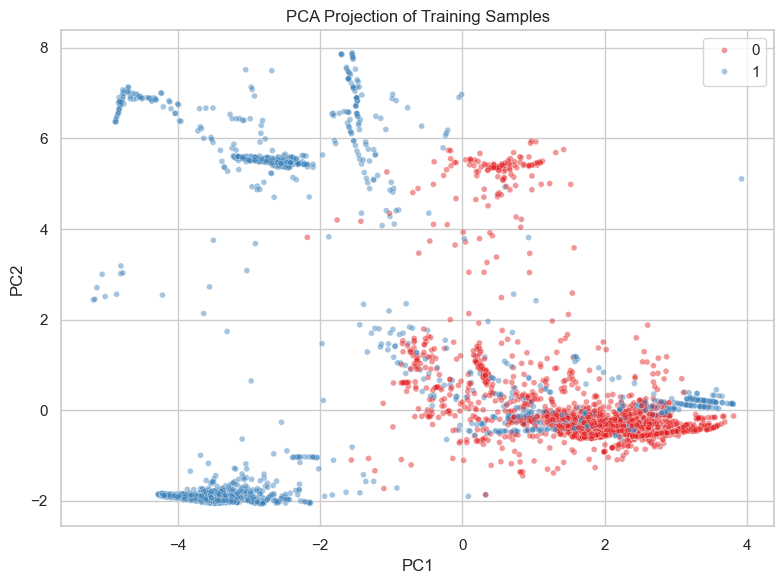

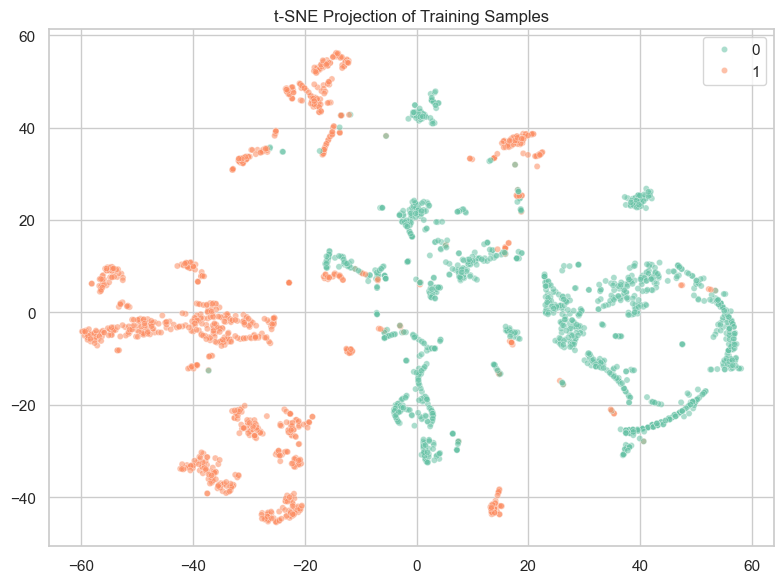

In [5]:
# Categorical behavior by binary class
eda_df = train_df.copy()
eda_df['binary_label'] = (eda_df['label'].astype(str) != 'normal').astype(int)

cat_show = ['protocol_type', 'service', 'flag']
fig, axes = plt.subplots(1, 3, figsize=(22, 5))
for ax, col in zip(axes, cat_show):
    top_vals = eda_df[col].value_counts().head(10).index
    tmp = eda_df[eda_df[col].isin(top_vals)]
    ct = pd.crosstab(tmp[col], tmp['binary_label'], normalize='columns').rename(columns={0: 'normal', 1: 'anomaly'})
    ct.plot(kind='bar', ax=ax)
    ax.set_title(f'{col} distribution by class (normalized)')
    ax.set_ylabel('ratio')
plt.tight_layout()
plt.show()

# KS ranking for numeric class-separation strength
ks_results = []
for c in num_cols_eda:
    normal_vals = train_df.loc[train_binary == 0, c].astype(float).values
    anomaly_vals = train_df.loc[train_binary == 1, c].astype(float).values
    stat, pval = ks_2samp(normal_vals, anomaly_vals)
    ks_results.append((c, stat, pval))
ks_df = pd.DataFrame(ks_results, columns=['feature', 'ks_stat', 'p_value']).sort_values('ks_stat', ascending=False)
display(ks_df.head(12))

# PCA and t-SNE sample views
target_cols_drop = ['label', 'difficulty']
X_eda = train_df.drop(columns=target_cols_drop).copy()
cat_cols_eda = X_eda.select_dtypes(include=['object']).columns.tolist()
if len(cat_cols_eda) > 0:
    enc_eda = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
    X_eda[cat_cols_eda] = enc_eda.fit_transform(X_eda[cat_cols_eda].astype(str))
X_eda = X_eda.fillna(X_eda.median(numeric_only=True))

scaler_eda = StandardScaler()
X_eda_scaled = scaler_eda.fit_transform(X_eda.values)

sample_n = min(6000, len(X_eda_scaled))
sample_idx = np.random.RandomState(SEED).choice(len(X_eda_scaled), size=sample_n, replace=False)
X_sample = X_eda_scaled[sample_idx]
y_sample = train_binary.values[sample_idx]

pca = PCA(n_components=2, random_state=SEED)
X_pca = pca.fit_transform(X_sample)
plt.figure(figsize=(8, 6))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=y_sample, alpha=0.45, s=18, palette='Set1')
plt.title('PCA Projection of Training Samples')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.tight_layout()
plt.show()

tsne_n = min(2500, len(X_sample))
tsne_idx = np.random.RandomState(SEED + 1).choice(len(X_sample), size=tsne_n, replace=False)
tsne = TSNE(n_components=2, perplexity=35, learning_rate='auto', init='pca', random_state=SEED)
X_tsne = tsne.fit_transform(X_sample[tsne_idx])
y_tsne = y_sample[tsne_idx]
plt.figure(figsize=(8, 6))
sns.scatterplot(x=X_tsne[:, 0], y=X_tsne[:, 1], hue=y_tsne, alpha=0.55, s=20, palette='Set2')
plt.title('t-SNE Projection of Training Samples')
plt.tight_layout()
plt.show()

In [6]:
# ---------- Preprocessing for ML ----------
y_train = (train_df['label'].astype(str) != 'normal').astype(int).values
y_test = (test_df['label'].astype(str) != 'normal').astype(int).values

X_train_raw = train_df.drop(columns=['label', 'difficulty']).copy()
X_test_raw = test_df.drop(columns=['label', 'difficulty']).copy()

common_cols = [c for c in X_train_raw.columns if c in X_test_raw.columns]
X_train_raw = X_train_raw[common_cols]
X_test_raw = X_test_raw[common_cols]

cat_cols = X_train_raw.select_dtypes(include=['object']).columns.tolist()
num_cols = [c for c in common_cols if c not in cat_cols]

for c in cat_cols:
    X_train_raw[c] = X_train_raw[c].fillna('Unknown').astype(str)
    X_test_raw[c] = X_test_raw[c].fillna('Unknown').astype(str)

for c in num_cols:
    med = X_train_raw[c].median()
    X_train_raw[c] = X_train_raw[c].fillna(med)
    X_test_raw[c] = X_test_raw[c].fillna(med)

ordinal_encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
if len(cat_cols) > 0:
    X_train_raw[cat_cols] = ordinal_encoder.fit_transform(X_train_raw[cat_cols])
    X_test_raw[cat_cols] = ordinal_encoder.transform(X_test_raw[cat_cols])

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_raw.values)
X_test = scaler.transform(X_test_raw.values)

feature_names = X_train_raw.columns.tolist()
X_train_normal = X_train[y_train == 0]

print('X_train:', X_train.shape, 'X_test:', X_test.shape)
print('Normal-only subset shape:', X_train_normal.shape)

def to_binary_from_anomaly_pred(pred):
    # anomaly estimators output 1=inlier, -1=outlier
    return np.where(pred == 1, 0, 1)

def anomaly_score(model, X):
    # Larger score = more anomalous
    if hasattr(model, 'decision_function'):
        return -model.decision_function(X)
    if hasattr(model, 'score_samples'):
        return -model.score_samples(X)
    return to_binary_from_anomaly_pred(model.predict(X)).astype(float)

def evaluate_model(name, model, X_eval, y_eval):
    raw_pred = model.predict(X_eval)
    y_pred = to_binary_from_anomaly_pred(raw_pred)
    score = anomaly_score(model, X_eval)

    acc = accuracy_score(y_eval, y_pred)
    precision, recall, f1, _ = precision_recall_fscore_support(y_eval, y_pred, average='binary')
    roc_auc = roc_auc_score(y_eval, score)
    pr_auc = average_precision_score(y_eval, score)

    print(f'\n{name}')
    print('-' * len(name))
    print(f'Accuracy={acc:.4f}  Precision={precision:.4f}  Recall={recall:.4f}  F1={f1:.4f}')
    print(f'ROC-AUC={roc_auc:.4f}  PR-AUC={pr_auc:.4f}')
    print('Confusion matrix:\n', confusion_matrix(y_eval, y_pred))
    print(classification_report(y_eval, y_pred, target_names=['normal', 'anomaly']))

    return {
        'model': name,
        'accuracy': acc,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'roc_auc': roc_auc,
        'pr_auc': pr_auc,
        'y_pred': y_pred,
        'score': score,
        'cm': confusion_matrix(y_eval, y_pred)
    }

X_train: (125973, 41) X_test: (22544, 41)
Normal-only subset shape: (67343, 41)


In [7]:
# ---------- Train and Evaluate ML Models ----------
iso_forest = IsolationForest(
    n_estimators=400,
    contamination='auto',
    random_state=SEED,
    n_jobs=-1
)
iso_forest.fit(X_train_normal)

lof = LocalOutlierFactor(
    n_neighbors=35,
    novelty=True,
    contamination='auto',
    n_jobs=-1
)
lof.fit(X_train_normal)

ocsvm = OneClassSVM(kernel='rbf', gamma='scale', nu=0.05)
ocsvm.fit(X_train_normal)

result_list = []
result_list.append(evaluate_model('Isolation Forest', iso_forest, X_test, y_test))
result_list.append(evaluate_model('Local Outlier Factor', lof, X_test, y_test))
result_list.append(evaluate_model('One-Class SVM', ocsvm, X_test, y_test))

summary_df = pd.DataFrame([{k: v for k, v in r.items() if k not in ['y_pred', 'score', 'cm']} for r in result_list])
display(summary_df.sort_values(['f1', 'pr_auc'], ascending=False))


Isolation Forest
----------------
Accuracy=0.8049  Precision=0.9718  Recall=0.6769  F1=0.7980
ROC-AUC=0.9371  PR-AUC=0.9527
Confusion matrix:
 [[9459  252]
 [4146 8687]]
              precision    recall  f1-score   support

      normal       0.70      0.97      0.81      9711
     anomaly       0.97      0.68      0.80     12833

    accuracy                           0.80     22544
   macro avg       0.83      0.83      0.80     22544
weighted avg       0.85      0.80      0.80     22544


Local Outlier Factor
--------------------
Accuracy=0.7661  Precision=0.8246  Recall=0.7483  F1=0.7846
ROC-AUC=0.8547  PR-AUC=0.8228
Confusion matrix:
 [[7669 2042]
 [3230 9603]]
              precision    recall  f1-score   support

      normal       0.70      0.79      0.74      9711
     anomaly       0.82      0.75      0.78     12833

    accuracy                           0.77     22544
   macro avg       0.76      0.77      0.76     22544
weighted avg       0.77      0.77      0.77     225

,model,accuracy,precision,recall,f1,roc_auc,pr_auc
0,Isolation Forest,0.804915,0.971809,0.676927,0.797997,0.937144,0.952667
1,Local Outlier Factor,0.766146,0.824646,0.748305,0.784623,0.854685,0.822815
2,One-Class SVM,0.783756,0.920258,0.678953,0.781400,0.866958,0.876493


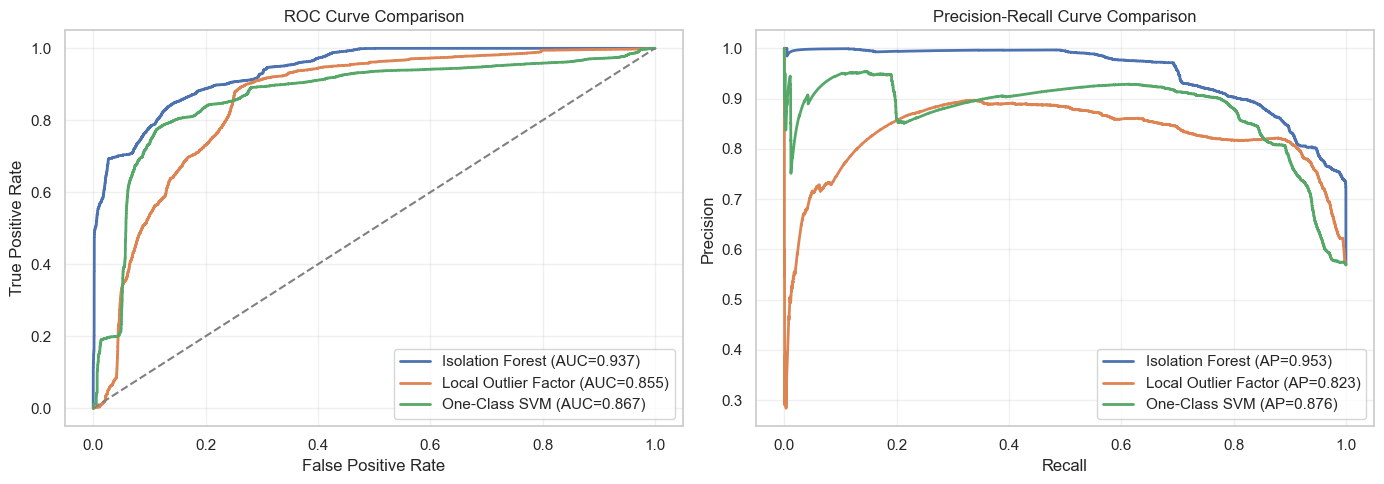

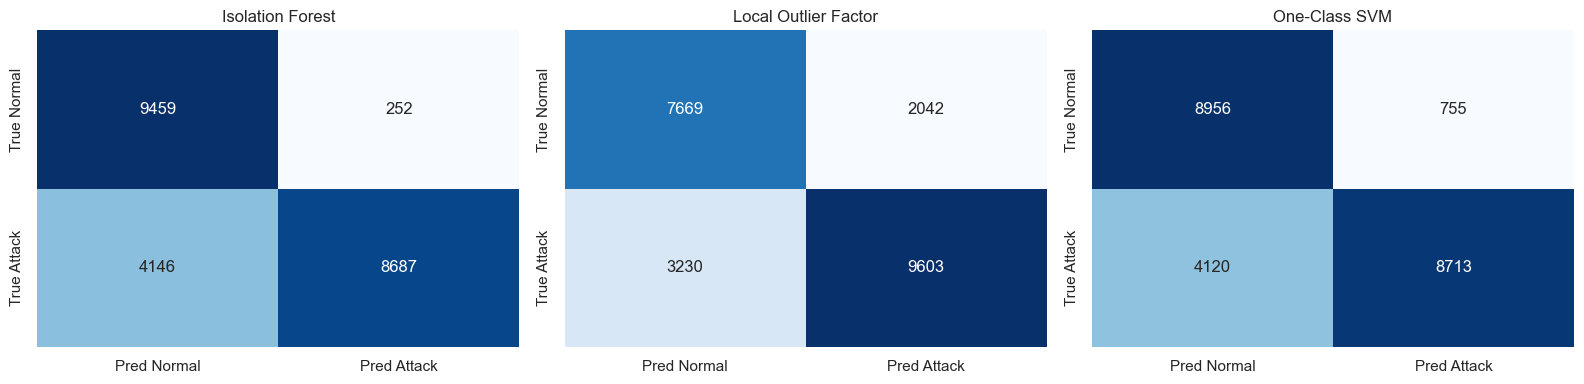

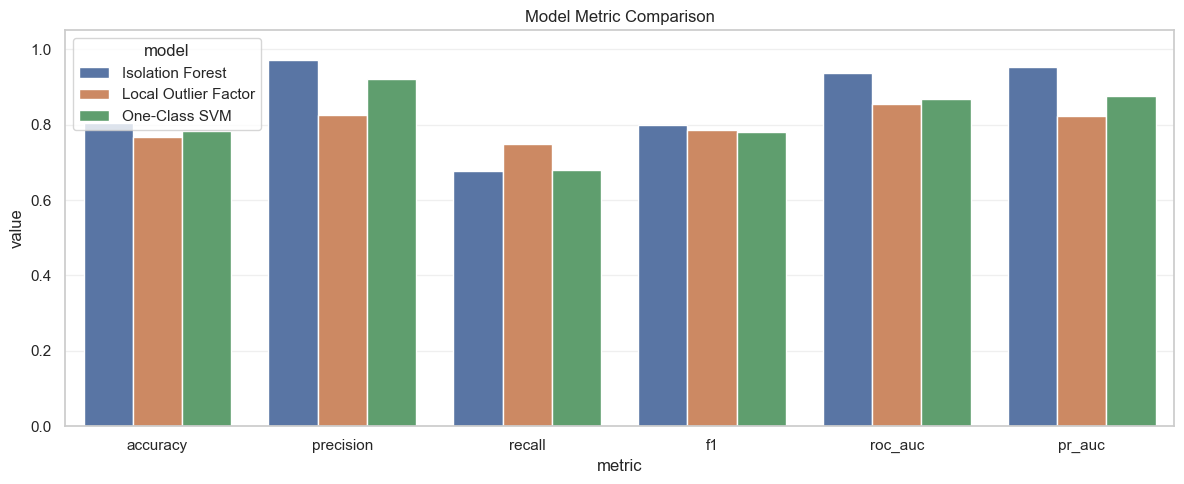

In [8]:
# ---------- Evaluation Dashboard ----------
res_map = {r['model']: r for r in result_list}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for model_name, r in res_map.items():
    fpr, tpr, _ = roc_curve(y_test, r['score'])
    prec, rec, _ = precision_recall_curve(y_test, r['score'])
    axes[0].plot(fpr, tpr, lw=2, label=f"{model_name} (AUC={r['roc_auc']:.3f})")
    axes[1].plot(rec, prec, lw=2, label=f"{model_name} (AP={r['pr_auc']:.3f})")

axes[0].plot([0, 1], [0, 1], linestyle='--', color='gray')
axes[0].set_title('ROC Curve Comparison')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].set_title('Precision-Recall Curve Comparison')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].legend()
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

fig, axs = plt.subplots(1, 3, figsize=(16, 4))
for ax, (model_name, r) in zip(axs, res_map.items()):
    sns.heatmap(
        r['cm'],
        annot=True, fmt='d', cmap='Blues', cbar=False,
        xticklabels=['Pred Normal', 'Pred Attack'],
        yticklabels=['True Normal', 'True Attack'],
        ax=ax
    )
    ax.set_title(model_name)
plt.tight_layout()
plt.show()

metric_cols = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc', 'pr_auc']
melt_df = summary_df.melt(id_vars='model', value_vars=metric_cols, var_name='metric', value_name='value')

plt.figure(figsize=(12, 5))
sns.barplot(data=melt_df, x='metric', y='value', hue='model')
plt.ylim(0, 1.05)
plt.title('Model Metric Comparison')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

Best model by F1/PR-AUC: Isolation Forest
Calibrated score threshold (max F1): -0.1098


,threshold,precision,recall,f1
0,-0.002099,0.971501,0.682693,0.801885
1,0.025150,0.975298,0.624562,0.761484
2,0.057479,0.983960,0.568846,0.720916
3,0.089966,0.991843,0.511650,0.675063
4,0.111303,0.996737,0.452271,0.622213
5,0.117534,0.996415,0.389854,0.560435
6,0.123506,0.996210,0.327749,0.493228
7,0.125961,0.995330,0.265721,0.419460
8,0.134186,0.994284,0.203304,0.337582
9,0.156711,0.996712,0.141744,0.248192


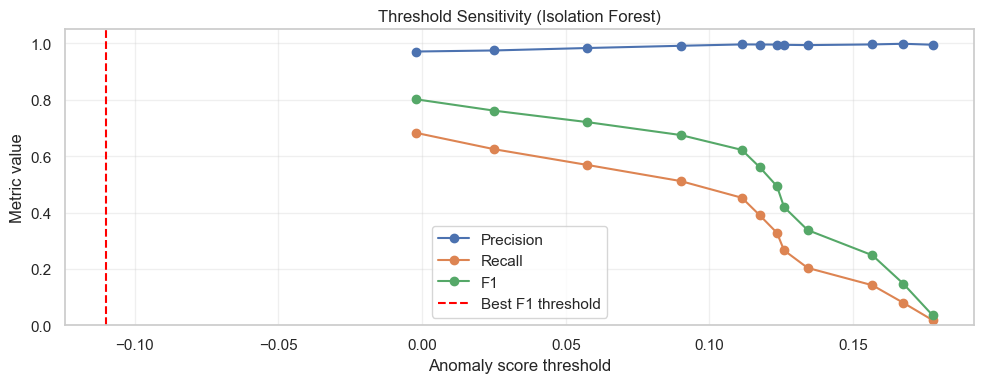

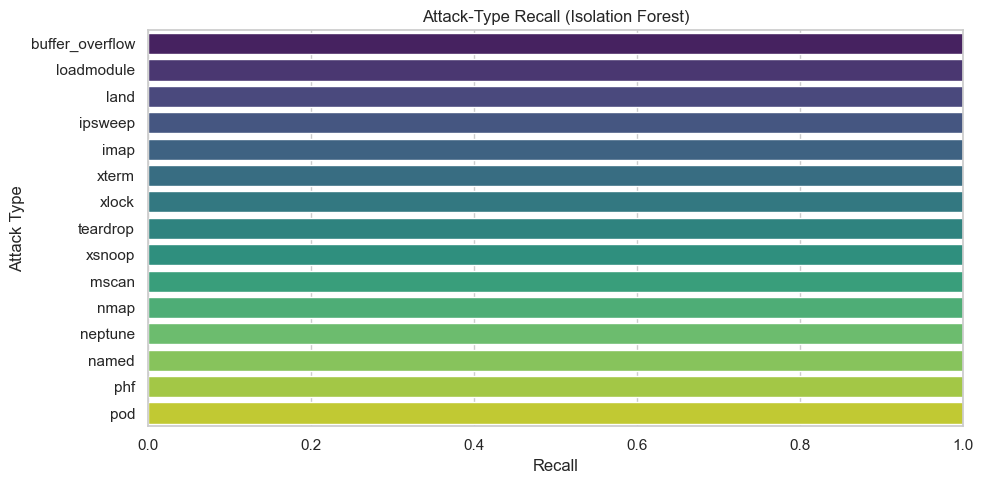

,label,recall
0,buffer_overflow,1.0
1,loadmodule,1.0
2,land,1.0
3,ipsweep,1.0
4,imap,1.0
5,xterm,1.0
6,xlock,1.0
7,teardrop,1.0
8,xsnoop,1.0
9,mscan,1.0


In [10]:
# ---------- Threshold Sensitivity & Attack-Type Recall ----------
from sklearn.metrics import precision_score, recall_score, f1_score

best_model = summary_df.sort_values(['f1', 'pr_auc'], ascending=False).iloc[0]['model']
best_res = res_map[best_model]
best_scores = best_res['score']

precision, recall, thresholds = precision_recall_curve(y_test, best_scores)
f1_vals = 2 * precision[:-1] * recall[:-1] / (precision[:-1] + recall[:-1] + 1e-12)
best_idx = int(np.argmax(f1_vals))
best_threshold = thresholds[best_idx] if len(thresholds) else np.percentile(best_scores, 95)

print(f"Best model by F1/PR-AUC: {best_model}")
print(f"Calibrated score threshold (max F1): {best_threshold:.4f}")

thr_grid = np.quantile(best_scores, np.linspace(0.60, 0.99, 12))
rows = []
for thr in thr_grid:
    y_pred_thr = (best_scores >= thr).astype(int)
    rows.append({
        'threshold': float(thr),
        'precision': precision_score(y_test, y_pred_thr, zero_division=0),
        'recall': recall_score(y_test, y_pred_thr, zero_division=0),
        'f1': f1_score(y_test, y_pred_thr, zero_division=0)
    })

thr_df = pd.DataFrame(rows)
display(thr_df.sort_values('f1', ascending=False).head(10))

plt.figure(figsize=(10, 4))
plt.plot(thr_df['threshold'], thr_df['precision'], marker='o', label='Precision')
plt.plot(thr_df['threshold'], thr_df['recall'], marker='o', label='Recall')
plt.plot(thr_df['threshold'], thr_df['f1'], marker='o', label='F1')
plt.axvline(best_threshold, color='red', linestyle='--', label='Best F1 threshold')
plt.title(f'Threshold Sensitivity ({best_model})')
plt.xlabel('Anomaly score threshold')
plt.ylabel('Metric value')
plt.ylim(0, 1.05)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

test_eval_df = test_df.copy()
test_eval_df['binary_label'] = (test_eval_df['label'] != 'normal').astype(int)
test_eval_df['anomaly_score'] = best_scores
test_eval_df['pred_attack'] = (test_eval_df['anomaly_score'] >= best_threshold).astype(int)

attack_recall = (
    test_eval_df[test_eval_df['label'] != 'normal']
    .groupby('label')
    .apply(lambda g: (g['pred_attack'] == 1).mean())
    .sort_values(ascending=False)
    .rename('recall')
    .reset_index()
    .head(15)
)

plt.figure(figsize=(10, 5))
sns.barplot(data=attack_recall, y='label', x='recall', palette='viridis')
plt.title(f'Attack-Type Recall ({best_model})')
plt.xlim(0, 1.0)
plt.xlabel('Recall')
plt.ylabel('Attack Type')
plt.tight_layout()
plt.show()

display(attack_recall)

In [12]:
# ---------- Save ML Artifacts ----------
joblib.dump(scaler, ARTIFACT_DIR / 'standard_scaler.joblib')
joblib.dump(ordinal_encoder, ARTIFACT_DIR / 'ordinal_encoder.joblib')
joblib.dump(feature_names, ARTIFACT_DIR / 'feature_names.joblib')
joblib.dump(cat_cols, ARTIFACT_DIR / 'categorical_columns.joblib')
joblib.dump(iso_forest, ARTIFACT_DIR / 'isolation_forest.joblib')
joblib.dump(lof, ARTIFACT_DIR / 'local_outlier_factor.joblib')
joblib.dump(ocsvm, ARTIFACT_DIR / 'oneclass_svm.joblib')

metadata = {
    'dataset': 'NSL-KDD',
    'label_mapping': {'normal': 0, 'attack': 1},
    'models': ['isolation_forest', 'local_outlier_factor', 'oneclass_svm'],
    'best_model': best_model,
    'best_threshold': float(best_threshold),
    'summary_metrics': summary_df.to_dict(orient='records')
}
with open(ARTIFACT_DIR / 'ml_metadata.json', 'w', encoding='utf-8') as f:
    json.dump(metadata, f, indent=2)

print('Saved artifacts to', ARTIFACT_DIR)

Saved artifacts to C:\Users\shain\Downloads\Network-Anomaly-Detection\checkpoints\ml_models_major


## Inference utility for custom CSV

Use the function below when you have a new NSL-KDD-format CSV. It returns binary predictions where `0=normal`, `1=anomaly`.

In [13]:
def predict_csv_with_model(csv_path: str, model_name: str = 'isolation_forest'):
    model_path = ARTIFACT_DIR / f'{model_name}.joblib'
    if not model_path.exists():
        raise FileNotFoundError(f'Model not found: {model_path}')

    model = joblib.load(model_path)
    scaler = joblib.load(ARTIFACT_DIR / 'standard_scaler.joblib')
    ordinal_encoder = joblib.load(ARTIFACT_DIR / 'ordinal_encoder.joblib')
    feature_names = joblib.load(ARTIFACT_DIR / 'feature_names.joblib')
    cat_cols = joblib.load(ARTIFACT_DIR / 'categorical_columns.joblib')

    df = pd.read_csv(csv_path, names=NSL_KDD_COLUMNS)
    X = df.drop(columns=['label', 'difficulty']).copy()

    for col in cat_cols:
        if col in X.columns:
            X[col] = X[col].fillna('Unknown').astype(str)

    X = X[feature_names]
    if len(cat_cols) > 0:
        X[cat_cols] = ordinal_encoder.transform(X[cat_cols])
    X_scaled = scaler.transform(X)
    pred = to_binary_from_anomaly_pred(model.predict(X_scaled))

    out = df.copy()
    out['pred_label'] = pred
    return out

# Example:
# preds = predict_csv_with_model((DATA_DIR / 'KDDTest+.txt').as_posix(), 'isolation_forest')
# preds[['label', 'pred_label']].head()